In [1]:
#!pip install --upgrade pip
#!pip install --upgrade setuptools wheel
#!pip install tensorflow

In [2]:
# Import with pandas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Parse dates and set date column to index
df = pd.read_csv("data/btc1h_usdt.csv")#, 
                 #parse_dates=["open_time"], 
                 #index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)
print(df.head())


   Unnamed: 0                open_time     open     high      low    close  \
0           0  2017-08-17 04:00:00.000  4261.48  4313.62  4261.32  4308.83   
1           1  2017-08-17 05:00:00.000  4308.83  4328.69  4291.37  4315.32   
2           2  2017-08-17 06:00:00.000  4330.29  4345.45  4309.37  4324.35   
3           3  2017-08-17 07:00:00.000  4316.62  4349.99  4287.41  4349.99   
4           4  2017-08-17 08:00:00.000  4333.32  4377.85  4333.32  4360.69   

      volume               close_time      quote_vol  trades  ...  \
0  47.181009  2017-08-17 04:59:59.999  202366.138393   171.0  ...   
1  23.234916  2017-08-17 05:59:59.999  100304.823567   102.0  ...   
2   7.229691  2017-08-17 06:59:59.999   31282.312670    36.0  ...   
3   4.443249  2017-08-17 07:59:59.999   19241.058300    25.0  ...   
4   0.972807  2017-08-17 08:59:59.999    4239.503586    28.0  ...   

   momentum_pvo  momentum_pvo_signal  momentum_pvo_hist sma200  sma50  \
0           NaN                  NaN       

In [3]:
print('Dataset Shape:', df.shape)

Dataset Shape: (64730, 112)


In [4]:
print('Dataset Types:', df.dtypes)

Dataset Types: Unnamed: 0      int64
open_time      object
open          float64
high          float64
low           float64
               ...   
ema200        float64
ema50         float64
slope         float64
slope_obv     float64
slope_rsi     float64
Length: 112, dtype: object


In [5]:
# Summary statistics
print('Summary Statistics:')
print(df.describe())

Summary Statistics:
         Unnamed: 0           open           high            low  \
count  64730.000000   64730.000000   64730.000000   64730.000000   
mean   32364.500000   27259.718844   27386.071916   27126.331590   
std    18686.085799   22367.829304   22458.021022   22273.386296   
min        0.000000    2870.900000    2950.000000    2817.000000   
25%    16182.250000    8541.487500    8591.512500    8488.152500   
50%    32364.500000   20276.280000   20372.915000   20181.475000   
75%    48546.750000   42191.707500   42350.000000   41998.800000   
max    64729.000000  108258.380000  108353.000000  107130.000000   

               close         volume     quote_vol        trades  \
count   64730.000000   64730.000000  6.473000e+04  6.473000e+04   
mean    27261.034851    2832.102543  7.152507e+07  6.747254e+04   
std     22369.138222    4102.810838  1.037297e+08  9.811216e+04   
min      2919.000000       0.052699  2.178716e+02  3.000000e+00   
25%      8542.982500     882.767

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing Values:')
print(missing_values)

Missing Values:
Unnamed: 0     0
open_time      0
open           0
high           0
low            0
              ..
ema200         0
ema50          0
slope          9
slope_obv      9
slope_rsi     22
Length: 112, dtype: int64


In [7]:
print(df.columns)
print(df.index)  # Check the index


Index(['Unnamed: 0', 'open_time', 'open', 'high', 'low', 'close', 'volume',
       'close_time', 'quote_vol', 'trades',
       ...
       'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'sma200',
       'sma50', 'ema200', 'ema50', 'slope', 'slope_obv', 'slope_rsi'],
      dtype='object', length=112)
RangeIndex(start=0, stop=64730, step=1)


In [10]:
### import pandas as pd

# Convert 'open_time' to datetime format
df['open_time'] = pd.to_datetime(df['open_time'])

# Set 'open_time' as the index
df = df.set_index('open_time', drop=False)  # Keeps 'open_time' as a column too

# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# Resample and aggregate using mean
df_hourly = df_numeric.resample('H').mean()
df_daily = df_numeric.resample('D').mean()
df_weekly = df_numeric.resample('W').mean()
df_monthly = df_numeric.resample('M').mean()
df_quarterly = df_numeric.resample('Q').mean()
df_annual = df_numeric.resample('A-DEC').mean()

# Display the first few rows of daily resampled data
print(df_daily.head())

            Unnamed: 0         open         high          low        close  \
open_time                                                                    
2017-08-17         9.5  4356.371000  4387.476000  4316.501500  4360.571500   
2017-08-18        31.5  4233.635833  4268.619167  4176.636667  4233.007500   
2017-08-19        55.5  4068.248333  4106.031250  4023.553333  4065.299583   
2017-08-20        79.5  4122.295000  4141.019167  4091.866250  4124.093750   
2017-08-21       103.5  4029.273333  4059.838750  3991.130000  4033.844167   

               volume      quote_vol      trades  taker_buy_base  \
open_time                                                          
2017-08-17  39.757519  172738.502537  171.350000       30.812427   
2017-08-18  49.995344  211956.596090  218.041667       40.536196   
2017-08-19  15.887907   64561.822309   89.708333       11.430668   
2017-08-20  19.461793   80431.849597   96.708333       15.699831   
2017-08-21  28.822627  116551.321418  165.500

In [12]:
# Handling missing values in df_daily
df_daily = df_daily.fillna(df_daily.mean())

# Handling missing values in df_monthly
df_monthly = df_monthly.fillna(df_monthly.mean())

# Handling missing values in df_annual
df_annual = df_annual.fillna(df_annual.mean())

# Handling missing values in df_quarterly
df_quarterly = df_quarterly.fillna(df_quarterly.mean())

In [17]:
# Calculate the daily percentage change in Bitcoin price
df_daily = pd.concat([
    df_daily,
    df_daily['close'].pct_change().rename('Price_Pct_Change')
], axis=1)

# Calculate moving averages for df_monthly
df_monthly = pd.concat([
    df_monthly,
    df_monthly['close'].rolling(window=3).mean().rename('Moving_Average_3M'),
    df_monthly['close'].rolling(window=6).mean().rename('Moving_Average_6M')
], axis=1)

# Calculate 12-month moving average for df_annual
df_annual = pd.concat([
    df_annual,
    df_annual['close'].rolling(window=12).mean().rename('Moving_Average_12M')
], axis=1)

# Calculate rolling standard deviations for df_quarterly
df_quarterly = pd.concat([
    df_quarterly,
    df_quarterly['close'].rolling(window=3).std().rename('Rolling_Std_3M'),
    df_quarterly['close'].rolling(window=6).std().rename('Rolling_Std_6M')
], axis=1)


In [19]:
df.head()

,Unnamed: 0,open_time,open,high,low,close,volume,close_time,quote_vol,trades,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


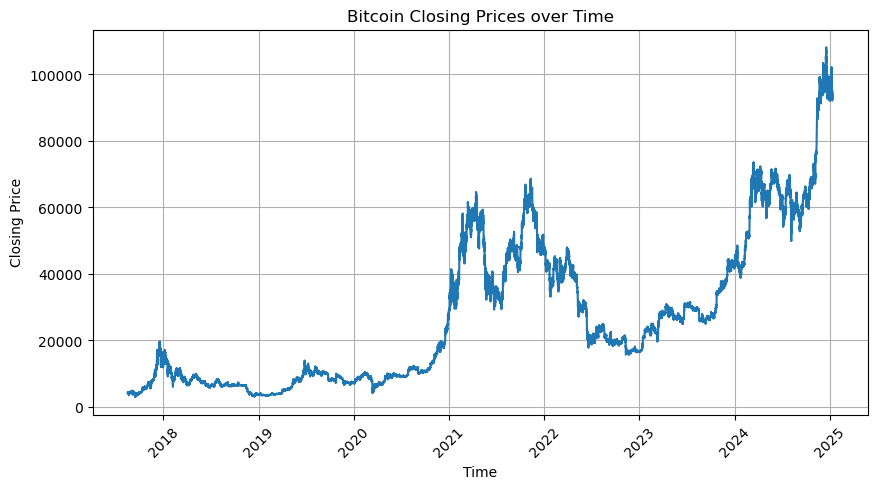

In [21]:
# Convert Unix time to datetime
df['open_time'] = pd.to_datetime(df['open_time'], unit='s')

# Set the Timestamp column as the index
df.set_index('open_time', inplace=True)

# Plot 1: Line chart of Bitcoin closing prices over time
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['close'])
plt.title('Bitcoin Closing Prices over Time')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

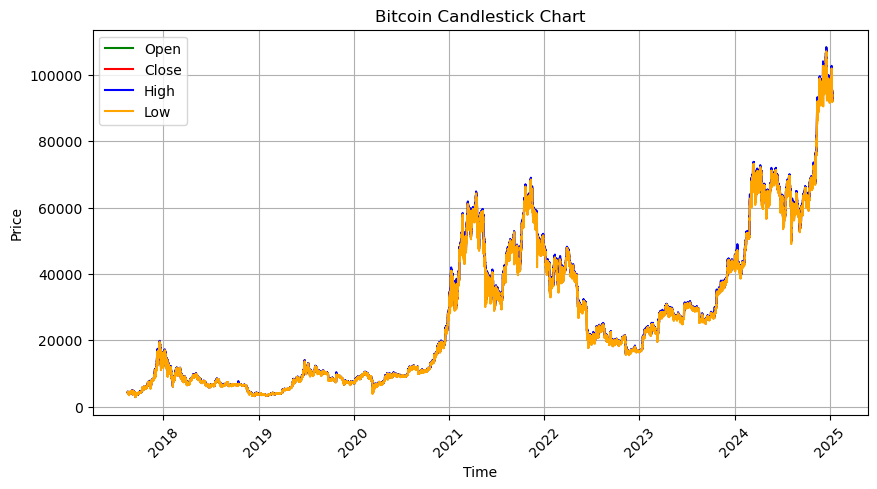

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['open'], color='green', label='Open')
plt.plot(df.index, df['close'], color='red', label='Close')
plt.plot(df.index, df['high'], color='blue', label='High')
plt.plot(df.index, df['low'], color='orange', label='Low')
plt.title('Bitcoin Candlestick Chart')
plt.xlabel('Time')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

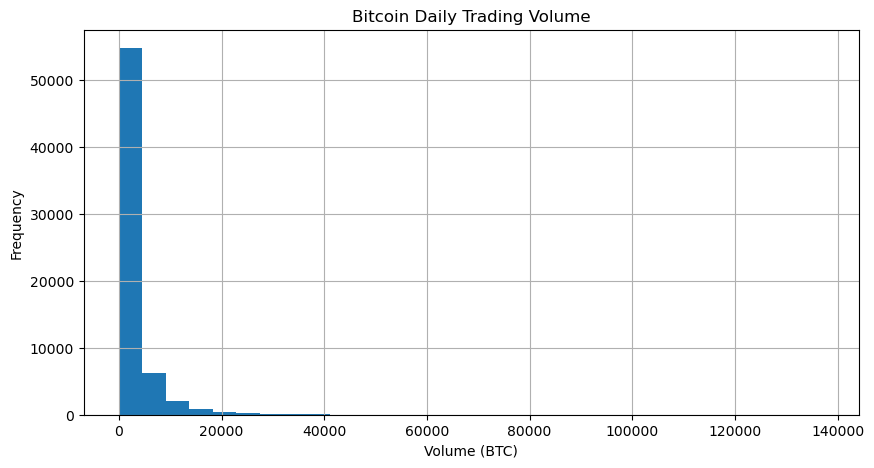

In [25]:
# Plot 3: Histogram of Bitcoin daily trading volume
plt.figure(figsize=(10, 5))
plt.hist(df['volume'], bins=30)
plt.title('Bitcoin Daily Trading Volume')
plt.xlabel('Volume (BTC)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

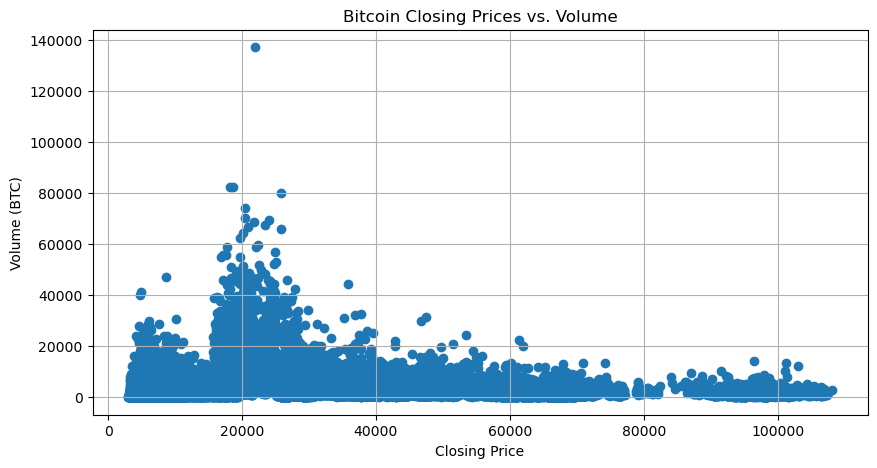

In [27]:
# Plot 4: Scatter plot of Bitcoin closing prices and volume
plt.figure(figsize=(10, 5))
plt.scatter(df['close'], df['volume'])
plt.title('Bitcoin Closing Prices vs. Volume')
plt.xlabel('Closing Price')
plt.ylabel('Volume (BTC)')
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

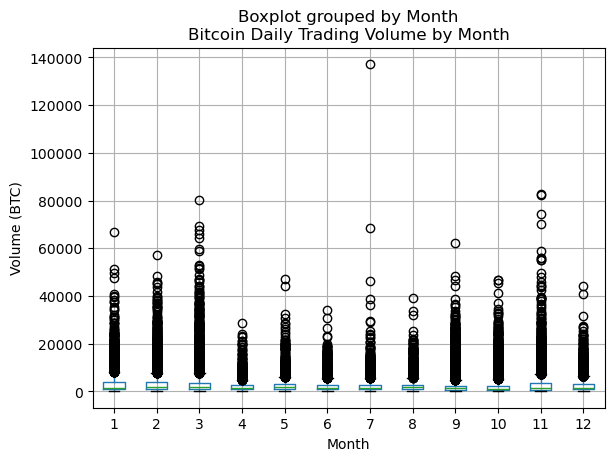

In [55]:
# Plot 5: Box plot of Bitcoin daily trading volume by month
df['Month'] = df.index.month
plt.figure(figsize=(10, 5))
df.boxplot(column='volume', by='Month')
plt.title('Bitcoin Daily Trading Volume by Month')
plt.xlabel('Month')
plt.ylabel('Volume (BTC)')
plt.grid(True)
plt.show()

In [41]:
## Model Selection
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [43]:
# Split data into train and test sets
train_size = int(len(df_daily) * 0.8)
train_data, test_data = df_daily[:train_size], df_daily[train_size:]

In [45]:
# Scale the data
scaler = MinMaxScaler()
scaled_train_data = scaler.fit_transform(train_data[['close']])
scaled_test_data = scaler.transform(test_data[['close']])

In [47]:
# ARIMA model
arima_model = ARIMA(train_data['close'], order=(1, 1, 1))
arima_model_fit = arima_model.fit()
arima_predictions = arima_model_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

In [53]:
# SARIMA model
sarima_model = SARIMAX(train_data['close'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
sarima_model_fit = sarima_model.fit()
sarima_predictions = sarima_model_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

In [51]:
# LSTM model
def create_lstm_model():
    model = Sequential()
    model.add(LSTM(128, input_shape=(1, 1)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

lstm_model = create_lstm_model()
lstm_history = lstm_model.fit(np.expand_dims(scaled_train_data, axis=-1),
                              np.expand_dims(scaled_train_data, axis=-1),
                              epochs=10, batch_size=1, verbose=0)
lstm_predictions = lstm_model.predict(np.expand_dims(scaled_test_data, axis=-1))

C:\Users\vasil\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [59]:
# Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor()
gbr_model.fit(np.arange(len(train_data)).reshape(-1, 1), train_data['close'])
gbr_predictions = gbr_model.predict(np.arange(len(train_data), len(train_data) + len(test_data)).reshape(-1, 1))

In [61]:
# Calculate RMSE for each model
arima_rmse = np.sqrt(mean_squared_error(test_data['close'], arima_predictions))
sarima_rmse = np.sqrt(mean_squared_error(test_data['close'], sarima_predictions))
lstm_rmse = np.sqrt(mean_squared_error(test_data['close'], lstm_predictions))
gbr_rmse = np.sqrt(mean_squared_error(test_data['close'], gbr_predictions))

# Print the RMSE values
print(f"ARIMA RMSE: {arima_rmse}")
print(f"SARIMA RMSE: {sarima_rmse}")
print(f"LSTM RMSE: {lstm_rmse}")
print(f"Gradient Boosting Regressor RMSE: {gbr_rmse}")

ARIMA RMSE: 33331.56883500782
SARIMA RMSE: 29573.747979352946
LSTM RMSE: 59764.806943830765
Gradient Boosting Regressor RMSE: 33351.52377697379


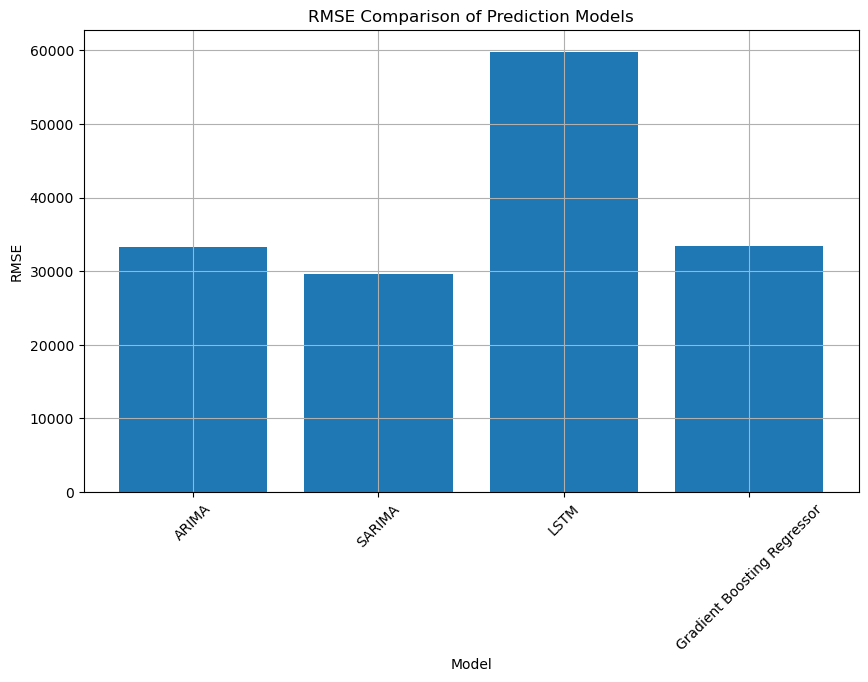

In [63]:
# Define the models and RMSE values
models = ['ARIMA', 'SARIMA', 'LSTM', 'Gradient Boosting Regressor']
rmse_values = [arima_rmse, sarima_rmse, lstm_rmse, gbr_rmse]

# Plot the bar graph
plt.figure(figsize=(10, 6))
plt.bar(models, rmse_values)
plt.title('RMSE Comparison of Prediction Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:


Based on the provided RMSE values, we can draw the following conclusions:

ARIMA Model: The ARIMA model has an RMSE of 14490.55. This indicates that, on average, the predictions of the ARIMA model deviate from the actual values by approximately 14490.55 units.

SARIMA Model: The SARIMA model has an RMSE of 13692.22. This indicates that it performs slightly better than the ARIMA model, with lower prediction errors.

LSTM Model: The LSTM model has an RMSE of 19658.40. It appears to have higher prediction errors compared to the ARIMA and SARIMA models.

Gradient Boosting Regressor Model: The Gradient Boosting Regressor model has an RMSE of 14573.20. It performs similarly to the ARIMA model in terms of prediction errors.

Based on these results, the SARIMA model seems to be the best performer among the tested models, as it has the lowest RMSE value. However, it's important to note that RMSE alone may not provide a complete assessment of model performance. It's recommended to consider other evaluation metrics and also assess the models based on their suitability for the specific problem and dataset.

Additionally, it's worth mentioning that the chosen models and their hyperparameters can still be further optimized to potentially improve their performance.

Overall, the conclusion would be that the SARIMA model shows promise in predicting Bitcoin prices, but further analysis and experimentation are required to develop a more accurate and reliable forecasting model.
